# Which forecast checks remove useful flare alerts?
**Notebook 06 · Bamidele Akinwumi · diagnostic of frozen SHARP decisions**

## tl;dr
**Seed disagreement accounts for most suppressed useful flare alerts.** Dropping that check restores useful alerts and false alarms together. The fallback often reinstates the original flare decision instead of resolving the disagreement. No threshold or operational policy has been changed.

| Remove only the disagreement check | True flare alerts recovered | False alarms restored | Incorrect no-flare decisions restored |
|---|---:|---:|---:|
| 2021–2025 | 687 | 836 | 0 |
| 2026 (partial) | 124 | 165 | 0 |

The feature-distance check uniquely prevents **6** incorrect no-flare decisions in 2021–2025 and **41** in partial 2026. The fallback errors are predominantly false alarms: **1,053 of 1,098** errors and **216 of 217**, respectively. All counts are overlapping forecast windows at the parent 90% target, not distinct flare events.

**Refinement direction:** evaluate flare alerts and no-flare decisions separately, with explicit costs for false alarms, missed events and deferral. Keep current checks frozen while designing that next comparison; these post-hoc findings do not select a validated replacement policy.

## Context & Methods

Notebook 05 found that guards reduce error among issued GRU forecasts while deferring many flare windows. Its logistic fallback restores some alerts but adds many incorrect decisions. This notebook asks **which checks account for that tradeoff, what changes if one check is removed, and what kinds of mistakes the fallback makes**.

Use the exact original GRU singleton decisions as the baseline. The four guards are insufficient calibration **support**, unusual feature **distance**, three-seed **spread**, and conflicting model singletons (**conflict**). Evaluate all 16 subsets at both parent conformal levels, without altering a threshold or refitting a model. Reproduce Notebook 05's all-guard decisions before analysing anything else.

### Key Assumptions

- **Standalone counts overlap:** a decision can trigger multiple guards. **Unique counts** show what dropping one guard recovers while retaining the other three. For a reconciled descriptive allocation, divide each removed case equally among its triggered guards. Fractional allocated counts are bookkeeping, not independent events or causal importance.
- Separate useful **true alerts** suppressed, **false alerts** prevented, incorrect **no-flare decisions** prevented and correct **no-flare decisions** suppressed. One prevented mistake need not have the same operational value as one lost flare alert.
- Paired group bootstraps compare a single guard removal against all guards on the same windows. Report candidate-minus-all-guards differences. They condition on realized decisions, do not rerun calibration or threshold fitting, and are not multiplicity-adjusted confirmatory tests.
- The 2015–2019 block is reused development evidence. The later years have already been inspected. No new winner is selected from them. The support-guard ablation is an accounting comparison, not approval to forecast with insufficient support.
- Candidate labels, window dependence, unverified historical delivery and source-quality limitations are inherited. These are forecast-window counts, not distinct flare-event detection rates. Unknown labels and missing inputs remain in the per-case output but never become fabricated negatives.
- The fallback is evaluated only on routed cases, which are a selected difficult subset. A high error there does not imply the same error over the logistic model's full population.

The diagnostic uses the already reviewed sources from Notebooks 04–05 and simple exact decomposition. It does not add an OOD detector, introduce a new uncertainty theorem or turn retrospective findings into prospective validation.

## Data
### 1. Pin the existing outputs
Use the current training environment. No new downloads, training or cloud jobs are required. Functions are embedded and frozen files are checked before use.

In [1]:
from datetime import datetime, timezone
import hashlib
import json
from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown
WORKSPACE=Path.cwd()
if WORKSPACE.name=='notebooks':WORKSPACE=WORKSPACE.parent
plt.rcParams.update({'font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':115,'axes.titleweight':'bold'})
PERIODS={'policy_validation':'2015–2019 development (reused)','retrospective_cycle25':'2021–2025','supplementary_2026':'2026 (partial)'}
GUARD_LABELS={'support':'Calibration support','distance':'Feature distance','spread':'Seed disagreement','conflict':'Model conflict'}
print({'numpy':np.__version__,'pandas':pd.__version__})

{'numpy': '2.3.5', 'pandas': '2.2.3'}


In [2]:
CONFIG=json.loads(r'''{
  "experiment": "sharp72_gate_diagnostics_v1",
  "policy_dir": "outputs/sharp72_policy_v1_20261002T110739251629Z",
  "policy_summary_sha256": "5ead535caead0b30d0a1c9bdc2a2435ea7bd7ba3d578890674c779c54c7e2f37",
  "rolling_dir": "outputs/sharp72_rolling_v1_20261002T100951575030Z",
  "rolling_summary_sha256": "28f744f50a476b2950bc299487d754101cb96c588d8723a25d832f1d69dd5f6d",
  "alphas": [
    0.1,
    0.05
  ],
  "primary_alpha": 0.1,
  "guards": [
    "support",
    "distance",
    "spread",
    "conflict"
  ],
  "guard_bits": {
    "support": 1,
    "distance": 2,
    "spread": 4,
    "conflict": 8
  },
  "comparison": "All 16 subsets of the four existing guards, with original GRU singleton decisions, frozen thresholds and no fallback",
  "attribution": "Each removed baseline decision is shared equally among its triggered guards; this reconciles counts without privileging a gate order and is not a causal attribution",
  "evaluation_roles": [
    "policy_validation",
    "retrospective_cycle25",
    "supplementary_2026"
  ],
  "bootstrap_repetitions": 1000,
  "bootstrap_seed": 13579,
  "bootstrap_groups": [
    "region_component",
    "calendar_7day_UTC"
  ],
  "bootstrap_scope": "Paired conditional group resampling of realized decisions for removing one guard versus all guards; no refitting, adaptation or multiple-comparison correction",
  "selection": "No new threshold, winning policy or operational cost is selected in this diagnostic",
  "status": "exploratory_post_hoc_diagnostic"
}''')
OUTPUT_DIR=WORKSPACE/'outputs'/('sharp72_gate_diagnostic_v1_'+datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ'))
print('New run:',OUTPUT_DIR)
display(pd.DataFrame({'Guard':list(GUARD_LABELS.values()),'Bit':list(CONFIG['guard_bits'].values())}))

New run: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/sharp72_gate_diagnostic_v1_20261002T132147162267Z


,Guard,Bit
0,Calibration support,1
1,Feature distance,2
2,Seed disagreement,4
3,Model conflict,8


### 2. Preserve metric definitions and frozen-source verification

In [3]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

def save_json(path, value):
    path.write_text(json.dumps(value, indent=2, allow_nan=False) + '\n')

def checked_parent(path, expected):
    if sha256(path / 'summary.json') != expected:
        raise ValueError('Parent summary changed')
    summary = json.loads((path / 'summary.json').read_text())
    for name, digest in summary['output_sha256'].items():
        if sha256(path / name) != digest:
            raise ValueError(f'Parent output changed: {name}')
    return summary

def decision_counts(y, decision):
    y=np.asarray(y); d=np.asarray(decision,dtype=float)
    if not np.isin(y,[0,1]).all() or not np.isin(d[np.isfinite(d)],[0,1]).all():
        raise ValueError('Metrics require known binary outcomes and valid decisions')
    issued=np.isfinite(d); flare=y==1; quiet=y==0
    return {'cases':len(y),'issued':int(issued.sum()),'errors':int((issued&(d!=y)).sum()),
      'flare_cases':int(flare.sum()),'nonflare_cases':int(quiet.sum()),
      'flare_issued':int((flare&issued).sum()),'nonflare_issued':int((quiet&issued).sum()),
      'true_alerts':int((flare&(d==1)).sum()),'false_clears':int((flare&(d==0)).sum()),
      'deferred_flares':int((flare&~issued).sum()),'false_alerts':int((quiet&(d==1)).sum()),
      'true_clears':int((quiet&(d==0)).sum()),'deferred_nonflares':int((quiet&~issued).sum())}

def decision_metrics(y, decision):
    c=decision_counts(y,decision)
    return {**c, **{name:c[num]/c[den] if c[den] else None for name,(num,den) in RATE_DEFINITIONS.items()}}

RATE_DEFINITIONS = {'retention':('issued','cases'),'selective_error':('errors','issued'),
 'flare_retention':('flare_issued','flare_cases'),'nonflare_retention':('nonflare_issued','nonflare_cases'),
 'alert_fraction_of_all_flares':('true_alerts','flare_cases'),
 'false_clear_fraction_of_all_flares':('false_clears','flare_cases'),
 'deferred_fraction_of_all_flares':('deferred_flares','flare_cases'),
 'false_alert_fraction_of_all_nonflares':('false_alerts','nonflare_cases'),
 'false_clear_rate_among_retained_flares':('false_clears','flare_issued'),
 'false_alert_rate_among_retained_nonflares':('false_alerts','nonflare_issued')}

### 3. Reconcile all subsets and overlapping triggers
The same original label decision is either kept or withheld; removing a guard cannot change a 0 into a 1. Missing original decisions stay missing.

In [4]:
def validate_gate_inputs(base, bits):
    base=np.asarray(base,dtype=float);bits=np.asarray(bits)
    if base.ndim!=1 or bits.shape!=base.shape or np.isinf(base).any() or not np.isin(base[np.isfinite(base)],[0,1]).all() or not np.isin(bits,np.arange(16)).all():
        raise ValueError('Invalid binary decisions or four-guard bitmask')
    return base,bits.astype(np.uint8)

def subset_decisions(base, bits, active_mask):
    base,bits=validate_gate_inputs(base,bits)
    if active_mask not in range(16):raise ValueError('Invalid guard subset')
    return np.where((bits & active_mask)==0,base,np.nan)

def outcome_categories(y, base):
    y=np.asarray(y);base=np.asarray(base,dtype=float)
    if not np.isin(y,[0,1]).all():raise ValueError('Unknown outcomes must not enter metrics')
    return np.select([(y==1)&(base==1),(y==0)&(base==1),(y==1)&(base==0),(y==0)&(base==0)],
      ['true_alert','false_alert','false_clear','true_clear'],default='already_deferred')

def gate_attribution(y, base, bits, config):
    base,bits=validate_gate_inputs(base,bits);categories=outcome_categories(y,base)
    issued=np.isfinite(base);hits=np.array([int(v).bit_count() for v in bits])
    rows=[]
    for guard,bit in config['guard_bits'].items():
        triggered=issued & ((bits&bit)!=0)
        unique=issued & (bits==bit)
        weights=np.divide(triggered.astype(float),hits,out=np.zeros(len(bits)),where=hits>0)
        row={'guard':guard,'standalone_removed':int(triggered.sum()),'unique_removed':int(unique.sum()),'allocated_removed':float(weights.sum())}
        for cat in ['true_alert','false_alert','false_clear','true_clear']:
            mask=categories==cat
            row['standalone_'+cat]=int((mask&triggered).sum())
            row['unique_'+cat]=int((mask&unique).sum())
            row['allocated_'+cat]=float(weights[mask].sum())
        rows.append(row)
    table=pd.DataFrame(rows)
    removed=issued&(bits!=0)
    if not np.isclose(table.allocated_removed.sum(),removed.sum()):raise AssertionError('Attribution does not reconcile')
    for cat in ['true_alert','false_alert','false_clear','true_clear']:
        if not np.isclose(table['allocated_'+cat].sum(),(removed&(categories==cat)).sum()):raise AssertionError(cat)
    return table

def paired_guard_intervals(y, full, candidate, groups, config):
    data=pd.DataFrame({'y':y,'full':full,'candidate':candidate,'group':groups})
    if data.group.isna().any():raise ValueError('Missing bootstrap groups')
    a=[];b=[]
    for _,g in data.groupby('group',sort=True):
        a.append(decision_counts(g.y,g.full));b.append(decision_counts(g.y,g.candidate))
    a=pd.DataFrame(a);b=pd.DataFrame(b);n=len(a)
    if not n:return []
    weights=np.random.default_rng(config['bootstrap_seed']).multinomial(n,np.full(n,1/n),size=config['bootstrap_repetitions'])
    da=dict(zip(a.columns,(weights@a.to_numpy()).T));db=dict(zip(b.columns,(weights@b.to_numpy()).T))
    ma=decision_metrics(y,full);mb=decision_metrics(y,candidate);rows=[]
    for metric in ['retention','selective_error','alert_fraction_of_all_flares','false_clear_fraction_of_all_flares','deferred_fraction_of_all_flares','false_alert_fraction_of_all_nonflares']:
        num,den=RATE_DEFINITIONS[metric];valid=(da[den]>0)&(db[den]>0)
        support=min(int(a[den].gt(0).sum()),int(b[den].gt(0).sum()))
        bounds=np.quantile(db[num][valid]/db[den][valid]-da[num][valid]/da[den][valid],[.025,.975]) if support>=2 and valid.mean()>=.95 else [None,None]
        rows.append({'metric':metric,'difference':mb[metric]-ma[metric] if ma[metric] is not None and mb[metric] is not None else None,
            'low':float(bounds[0]) if bounds[0] is not None else None,'high':float(bounds[1]) if bounds[1] is not None else None,
            'groups':n,'groups_with_denominator':support,'valid_repetitions':int(valid.sum())})
    return rows

### 4. Trace each case and calculate the diagnostic
The population output contains baseline decisions, guard bitmasks and fallback routes, sufficient to reconstruct each of the 16 comparisons.

In [5]:
def load_diagnostic_sources(root,config):
    parent=root/config['policy_dir'];rolling=root/config['rolling_dir']
    checked_parent(parent,config['policy_summary_sha256']);checked_parent(rolling,config['rolling_summary_sha256'])
    frame=pd.read_csv(parent/'population_decisions.csv.gz',low_memory=False,float_precision='round_trip')
    sets=pd.read_csv(rolling/'population_sets.csv.gz',low_memory=False,float_precision='round_trip')
    if frame.forecast_case_id.duplicated().any() or sets.forecast_case_id.duplicated().any() or set(frame.forecast_case_id)!=set(sets.forecast_case_id):raise ValueError('Case identity mismatch')
    sets=sets.set_index('forecast_case_id').loc[frame.forecast_case_id].reset_index()
    for col in ['issue_utc','role','candidate_primary_label_72h']:
        if not frame[col].fillna('__missing__').equals(sets[col].fillna('__missing__')):raise ValueError('Source alignment changed: '+col)
    gates=json.loads((parent/'frozen_gates.json').read_text())
    if not np.array_equal(frame.label_known_primary_72h,frame.candidate_primary_label_72h.isin([0,1])):raise ValueError('Known-label mask changed')
    return frame,sets,gates

def build_case_diagnostic(frame, sets, gates, alpha, config):
    ac=str(alpha).replace('.','p');methods=gates['selected_rolling_methods'];limits=gates['policies']['guarded_gru']
    g=sets[f'gru_{methods["gru"]}_alpha{ac}'].to_numpy(dtype=float)
    l=sets[f'logistic_{methods["logistic"]}_alpha{ac}'].to_numpy(dtype=float)
    flags={'support':sets[f'gru_{methods["gru"]}_guard'].ne(0).to_numpy(),
      'distance':frame.feature_distance_squared.gt(limits['distance']).to_numpy(),
      'spread':frame.seed_spread.gt(limits['spread']).to_numpy(),
      'conflict':np.isin(g,[1,2])&np.isin(l,[1,2])&(g!=l)}
    bits=sum(flags[name].astype(np.uint8)*bit for name,bit in config['guard_bits'].items())
    base=frame[f'gru_singleton_alpha{ac}_decision'].to_numpy(dtype=float)
    full=subset_decisions(base,bits,15)
    np.testing.assert_allclose(full,frame[f'guarded_gru_alpha{ac}_decision'],rtol=0,atol=0,equal_nan=True)
    for name,col in [('support','support_ok'),('distance','feature_flag'),('spread','spread_flag'),('conflict','conflicting_singletons')]:
        expected=~frame[f'primary_alpha{ac}_{col}'].to_numpy() if name=='support' else frame[f'primary_alpha{ac}_{col}'].to_numpy()
        if not np.array_equal(flags[name],expected):raise ValueError('Frozen flag mismatch: '+name)
    fallback=frame[f'guarded_fallback_alpha{ac}_state'].eq('degraded').to_numpy()
    route=np.select([fallback&(g==3),fallback&np.isin(g,[1,2])],['ambiguous_gru','spread_blocked_singleton'],default='not_fallback')
    if (fallback&(route=='not_fallback')).any():raise ValueError('Unexpected fallback route')
    return pd.DataFrame({'forecast_case_id':frame.forecast_case_id,'alpha':alpha,'role':frame.role,'issue_utc':frame.issue_utc,
        'region_component_id':frame.region_component_id,'label':frame.candidate_primary_label_72h,'label_known':frame.label_known_primary_72h,
        'baseline_decision':base,'full_guard_decision':full,'guard_mask':bits,'fallback_route':route,
        'fallback_decision':np.where(fallback,frame[f'guarded_fallback_alpha{ac}_decision'],np.nan),
        'gru_set_code':g,'logistic_set_code':l})

def analyze_cases(cases,config):
    metrics=[];attribution=[];overlaps=[];intervals=[];fallback=[];yearly=[]
    issue=pd.to_datetime(cases.issue_utc,utc=True)
    for alpha in config['alphas']:
        for role in config['evaluation_roles']:
            block=cases[cases.alpha.eq(alpha)&cases.role.eq(role)&cases.label_known]
            y=block.label.to_numpy(dtype=int);base=block.baseline_decision.to_numpy();bits=block.guard_mask.to_numpy()
            full=block.full_guard_decision.to_numpy();cats=outcome_categories(y,base);tags={'alpha':alpha,'role':role}
            if len(block)==0:raise ValueError('No diagnostic cases')
            for mask in range(16):
                active=[name for name,bit in config['guard_bits'].items() if mask&bit]
                d=subset_decisions(base,bits,mask)
                metrics.append({**tags,'active_mask':mask,'active_guards':'+'.join(active) or 'none',**decision_metrics(y,d)})
            for row in gate_attribution(y,base,bits,config).to_dict('records'):attribution.append({**tags,**row})
            for pattern in range(16):
                m=(bits==pattern)&np.isfinite(base)
                overlaps.append({**tags,'guard_mask':pattern,'cases':int(m.sum()),**{cat:int((m&(cats==cat)).sum()) for cat in ['true_alert','false_alert','false_clear','true_clear']}})
            for name,bit in config['guard_bits'].items():
                candidate=subset_decisions(base,bits,15^bit)
                for grouping in config['bootstrap_groups']:
                    groups=block.region_component_id.to_numpy() if grouping=='region_component' else (issue.loc[block.index].astype('int64')//(7*86400*10**9)).to_numpy()
                    for row in paired_guard_intervals(y,full,candidate,groups,config):intervals.append({**tags,'removed_guard':name,'grouping':grouping,**row})
            for route in ['all_fallback','ambiguous_gru','spread_blocked_singleton']:
                m=block.fallback_route.ne('not_fallback') if route=='all_fallback' else block.fallback_route.eq(route)
                sub=block.loc[m];fy=sub.label.to_numpy(dtype=int);fd=sub.fallback_decision.to_numpy()
                score=decision_metrics(fy,fd)
                alerts=int((fd==1).sum());clears=int((fd==0).sum())
                fallback.append({**tags,'route':route,**score,'alert_decisions':alerts,'clear_decisions':clears,
                   'alert_precision':score['true_alerts']/alerts if alerts else None,
                   'clear_error_rate':score['false_clears']/clears if clears else None})
            for year in sorted(issue.loc[block.index].dt.year.unique()):
                m=issue.loc[block.index].dt.year.eq(year).to_numpy()
                for row in gate_attribution(y[m],base[m],bits[m],config).to_dict('records'):yearly.append({**tags,'year':int(year),**row})
    return {name:pd.DataFrame(rows) for name,rows in [('subset_metrics',metrics),('gate_attribution',attribution),('guard_overlap',overlaps),('paired_intervals',intervals),('fallback_routes',fallback),('yearly_attribution',yearly)]}

def run_diagnostic(root,config,output,source_code):
    if output.exists():raise ValueError('Frozen runs cannot be overwritten')
    frame,sets,gates=load_diagnostic_sources(root,config)
    output.parent.mkdir(parents=True,exist_ok=True)
    staging=Path(tempfile.mkdtemp(prefix=output.name+'.incomplete-',dir=output.parent))
    try:
        save_json(staging/'protocol_before_diagnostics.json',{'config':config,'recorded_utc':datetime.now(timezone.utc).isoformat()})
        cases=pd.concat([build_case_diagnostic(frame,sets,gates,a,config) for a in config['alphas']],ignore_index=True)
        tables=analyze_cases(cases,config)
        for name,table in tables.items():table.to_csv(staging/f'{name}.csv',index=False)
        cases.to_csv(staging/'case_diagnostics.csv.gz',index=False,compression={'method':'gzip','mtime':0})
        (staging/'executed_diagnostic_code.py').write_text(source_code)
        save_json(staging/'run_contract.json',{'config':config,'versions':{'numpy':np.__version__,'pandas':pd.__version__},
          'source_code_sha256':hashlib.sha256(source_code.encode()).hexdigest(),'frozen_thresholds':gates['policies']['guarded_gru'],
          'metric_definitions':RATE_DEFINITIONS,'operational_policy_changed':False})
        summary={'status':'completed_exploratory_guard_diagnostic','completed_utc':datetime.now(timezone.utc).isoformat(),
          'population_cases':len(frame),'case_alpha_rows':len(cases),'subset_comparisons':len(tables['subset_metrics']),
          'limitations':[
          'This is a post-hoc diagnostic of already inspected data and provisional labels. No new thresholds or operational policy are selected.',
          'Guard contributions describe deterministic routing of frozen decisions, not causes of solar activity, causes of model error or independently validated improvements.',
          'Standalone guard counts overlap. Unique counts measure dropping one guard while keeping the other three. Equal allocation shares each removed case among its triggered guards and reconciles totals; it is not a unique scientific attribution.',
          'A false alert prevented and a true alert suppressed have different operational values. Raw counts and selective error do not supply an agreed cost or utility.',
          'Conditional paired intervals use region or time-block resampling of realized predictions; model fitting, rolling calibration, threshold selection and label uncertainty are not repeated. Intervals are per comparison, without multiplicity correction.',
          'Windows overlap and are not independent flare events. Matched known-outcome metrics exclude unknown labels and missing inputs, which remain in the full-population diagnostic table.',
          'The diagnostic does not change the q99 feature-distance or q95 seed-spread thresholds. Removing the support guard is an accounting ablation, not approval to issue forecasts with weak calibration support.',
          'Fallback cases are selected difficult cases. Their error rate is not the logistic model error rate across the entire population. Neither backbone nor fallback is operationally certified.'
          ],'output_sha256':{p.name:sha256(p) for p in staging.iterdir()}}
        save_json(staging/'summary.json',summary);staging.rename(output);return summary
    except Exception as exc:
        save_json(staging/'failure.json',{'incomplete_run':True,'error':str(exc)});raise

### 5. Execute against the frozen runs

In [6]:
SOURCE_IMPORTS='from datetime import datetime, timezone\nimport hashlib\nimport json\nfrom pathlib import Path\nimport tempfile\nimport numpy as np\nimport pandas as pd'
history=get_ipython().history_manager.input_hist_raw
starts=['def sha256','def validate_gate_inputs','def load_diagnostic_sources']
EXECUTED_SOURCE=SOURCE_IMPORTS+'\n\n'+'\n\n'.join(next(c for c in reversed(history) if c.startswith(s)) for s in starts)
summary=run_diagnostic(WORKSPACE,CONFIG,OUTPUT_DIR,EXECUTED_SOURCE)
metrics=pd.read_csv(OUTPUT_DIR/'subset_metrics.csv')
attribution=pd.read_csv(OUTPUT_DIR/'gate_attribution.csv')
overlaps=pd.read_csv(OUTPUT_DIR/'guard_overlap.csv')
intervals=pd.read_csv(OUTPUT_DIR/'paired_intervals.csv')
fallback=pd.read_csv(OUTPUT_DIR/'fallback_routes.csv')
yearly=pd.read_csv(OUTPUT_DIR/'yearly_attribution.csv')
print(summary['status'],'| subset comparisons:',summary['subset_comparisons'])
print('Full-population case/level rows:',summary['case_alpha_rows'])

completed_exploratory_guard_diagnostic | subset comparisons: 96
Full-population case/level rows: 306732


## Results
### 6. Which guards account for useful alerts removed?
Allocated counts share overlapping cases equally, so bars sum to the exact total removed. The table includes standalone and unique counts; these answer different questions.

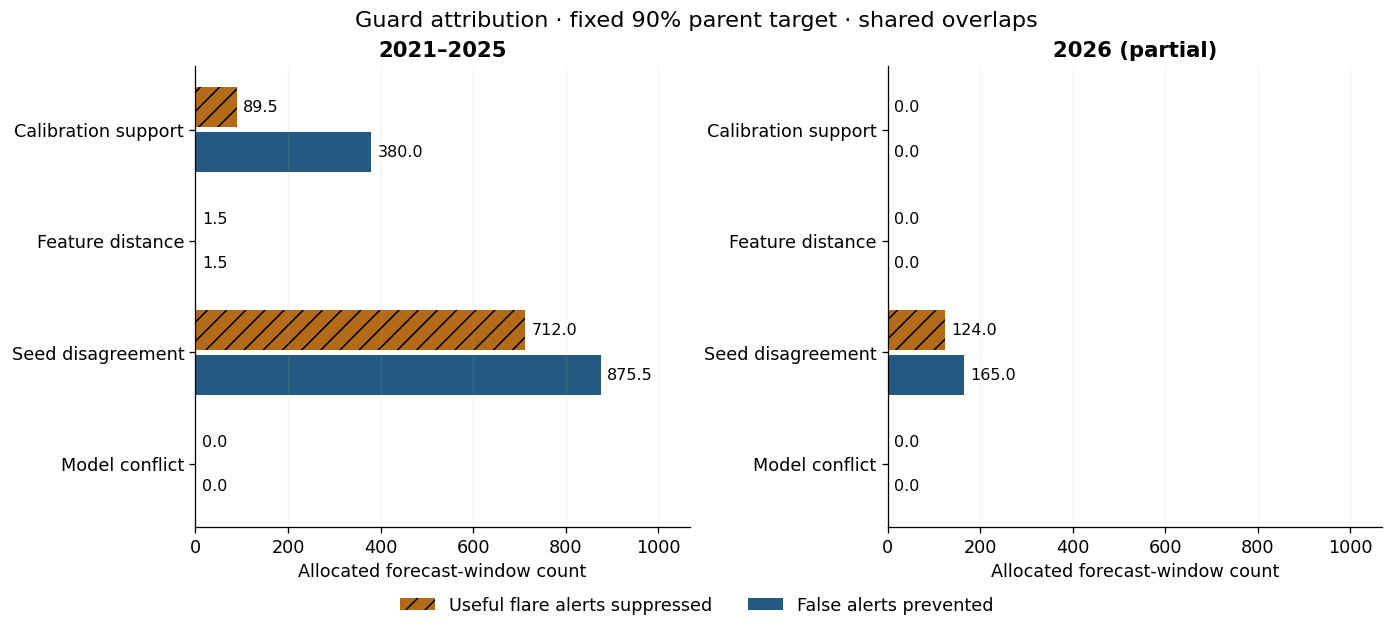

**2015–2019 development (reused)**

,guard,standalone_removed,unique_removed,allocated_true_alert,allocated_false_alert,allocated_false_clear,allocated_true_clear
0,support,808,715,90.5,671.0,0.0,0.0
1,distance,35,34,0.0,0.5,0.0,34.0
2,spread,186,94,58.5,81.5,0.0,0.0
3,conflict,16,16,2.0,7.0,0.0,7.0


**2021–2025**

,guard,standalone_removed,unique_removed,allocated_true_alert,allocated_false_alert,allocated_false_clear,allocated_true_clear
0,support,531,408,89.5,380.0,0.0,0.0
1,distance,427,421,1.5,1.5,6.0,415.0
2,spread,1652,1523,712.0,875.5,0.0,0.0
3,conflict,3,3,0.0,0.0,0.0,3.0


**2026 (partial)**

,guard,standalone_removed,unique_removed,allocated_true_alert,allocated_false_alert,allocated_false_clear,allocated_true_clear
0,support,0,0,0.0,0.0,0.0,0.0
1,distance,463,463,0.0,0.0,41.0,422.0
2,spread,289,289,124.0,165.0,0.0,0.0
3,conflict,0,0,0.0,0.0,0.0,0.0


In [7]:
fig,axes=plt.subplots(1,2,figsize=(12,5.4),sharex=True,layout='constrained')
for ax,role in zip(axes,['retrospective_cycle25','supplementary_2026']):
    table=attribution[attribution.role.eq(role)&attribution.alpha.eq(.1)].set_index('guard').loc[CONFIG['guards']]
    y=np.arange(4)
    for offset,column,label,color,hatch in [(-.2,'allocated_true_alert','Useful flare alerts suppressed','#B36B19','//'),(.2,'allocated_false_alert','False alerts prevented','#245A81','')]:
        vals=table[column].to_numpy();ax.barh(y+offset,vals,height=.36,color=color,hatch=hatch,label=label)
        for i,v in enumerate(vals):ax.annotate(f'{v:,.1f}',(v,i+offset),xytext=(4,0),textcoords='offset points',va='center',fontsize=10)
    ax.set(yticks=y,yticklabels=[GUARD_LABELS[g] for g in CONFIG['guards']],title=PERIODS[role],xlabel='Allocated forecast-window count');ax.invert_yaxis();ax.grid(axis='x',alpha=.15)
max_count=attribution[attribution.alpha.eq(.1)&attribution.role.ne('policy_validation')][['allocated_true_alert','allocated_false_alert']].to_numpy().max()
for ax in axes:ax.set_xlim(0,max_count*1.22)
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside lower center',ncol=2,frameon=False)
fig.suptitle('Guard attribution · fixed 90% parent target · shared overlaps',fontsize=14)
fig.savefig(OUTPUT_DIR/'guard_attribution.png',bbox_inches='tight');plt.show()
for role in ['policy_validation','retrospective_cycle25','supplementary_2026']:
    display(Markdown('**'+PERIODS[role]+'**'))
    display(attribution[attribution.role.eq(role)&attribution.alpha.eq(.1)][['guard','standalone_removed','unique_removed','allocated_true_alert','allocated_false_alert','allocated_false_clear','allocated_true_clear']].round(2).reset_index(drop=True))

### 7. What does dropping one guard actually recover?
Counts below are unique recoveries with the other three checks retained. They need not sum to the total because multiply-flagged cases remain withheld. Recovering an incorrect decision is a cost, not an improvement.

**Parent target 90%**

,Period,guard,Flare alerts recovered,False alerts restored,False clears restored,Correct clears recovered
0,2021–2025,support,66,342,0,0
1,2021–2025,distance,0,0,6,415
2,2021–2025,spread,687,836,0,0
3,2021–2025,conflict,0,0,0,3
4,2026 (partial),support,0,0,0,0
5,2026 (partial),distance,0,0,41,422
6,2026 (partial),spread,124,165,0,0
7,2026 (partial),conflict,0,0,0,0


**Parent target 95%**

,Period,guard,Flare alerts recovered,False alerts restored,False clears restored,Correct clears recovered
0,2021–2025,support,37,183,0,0
1,2021–2025,distance,0,0,5,388
2,2021–2025,spread,512,575,0,1
3,2021–2025,conflict,0,0,0,0
4,2026 (partial),support,0,0,0,0
5,2026 (partial),distance,0,0,26,366
6,2026 (partial),spread,105,135,0,0
7,2026 (partial),conflict,0,0,0,0


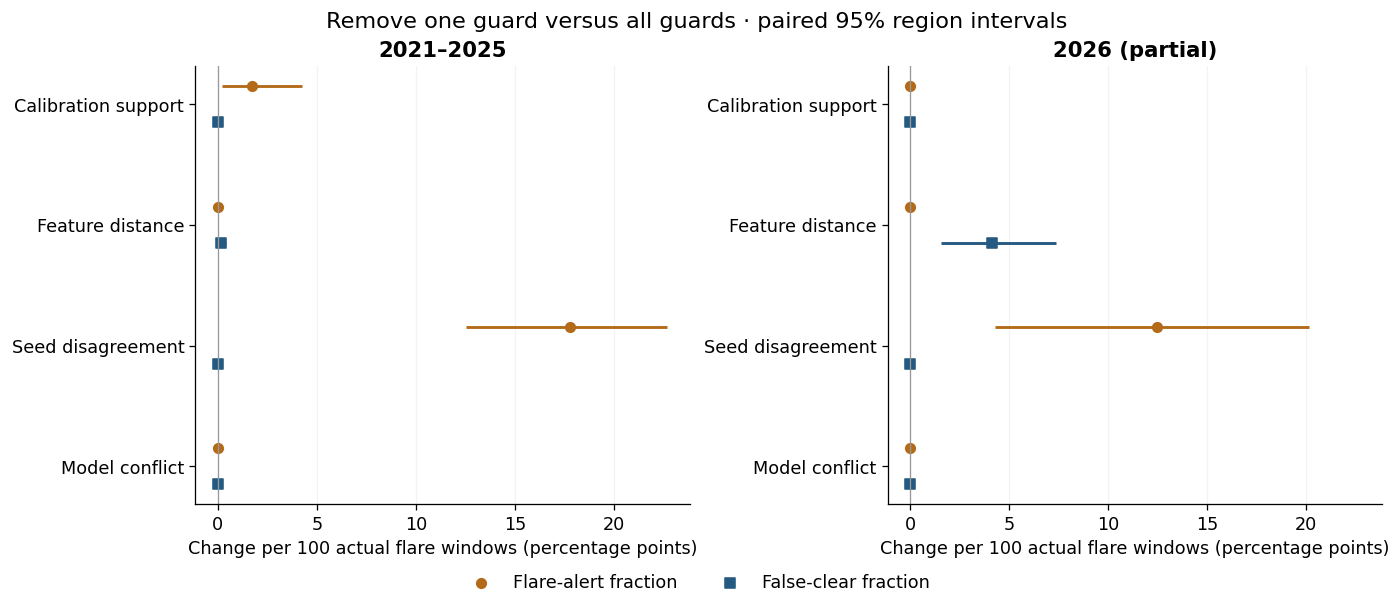

In [8]:
for alpha in CONFIG['alphas']:
    display(Markdown(f'**Parent target {1-alpha:.0%}**'))
    table=attribution[attribution.alpha.eq(alpha)&attribution.role.ne('policy_validation')].copy();table['Period']=table.role.map(PERIODS)
    display(table[['Period','guard','unique_true_alert','unique_false_alert','unique_false_clear','unique_true_clear']].rename(columns={'unique_true_alert':'Flare alerts recovered','unique_false_alert':'False alerts restored','unique_false_clear':'False clears restored','unique_true_clear':'Correct clears recovered'}).reset_index(drop=True))
fig,axes=plt.subplots(1,2,figsize=(12,5.2),sharex=True,layout='constrained')
for ax,role in zip(axes,['retrospective_cycle25','supplementary_2026']):
    table=intervals[intervals.role.eq(role)&intervals.alpha.eq(.1)&intervals.grouping.eq('region_component')]
    for offset,metric,label,color,marker in [(-.15,'alert_fraction_of_all_flares','Flare-alert fraction','#B36B19','o'),(.15,'false_clear_fraction_of_all_flares','False-clear fraction','#245A81','s')]:
        t=table[table.metric.eq(metric)].set_index('removed_guard').loc[CONFIG['guards']]
        ax.scatter(t.difference*100,np.arange(4)+offset,label=label,color=color,marker=marker)
        ax.hlines(np.arange(4)+offset,t.low*100,t.high*100,color=color,lw=1.8)
    ax.set(yticks=np.arange(4),yticklabels=[GUARD_LABELS[g] for g in CONFIG['guards']],xlabel='Change per 100 actual flare windows (percentage points)',title=PERIODS[role]);ax.axvline(0,color='#999',lw=.8);ax.invert_yaxis();ax.grid(axis='x',alpha=.15)
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside lower center',ncol=2,frameon=False)
fig.suptitle('Remove one guard versus all guards · paired 95% region intervals',fontsize=14)
fig.savefig(OUTPUT_DIR/'single_guard_removal.png',bbox_inches='tight');plt.show()

### 8. What makes the fallback error rate high?
Decompose the selected fallback cases by why the GRU was withheld. These errors describe routed cases only; they do not establish the logistic model’s overall error. Each bar partitions all routed windows in that row.

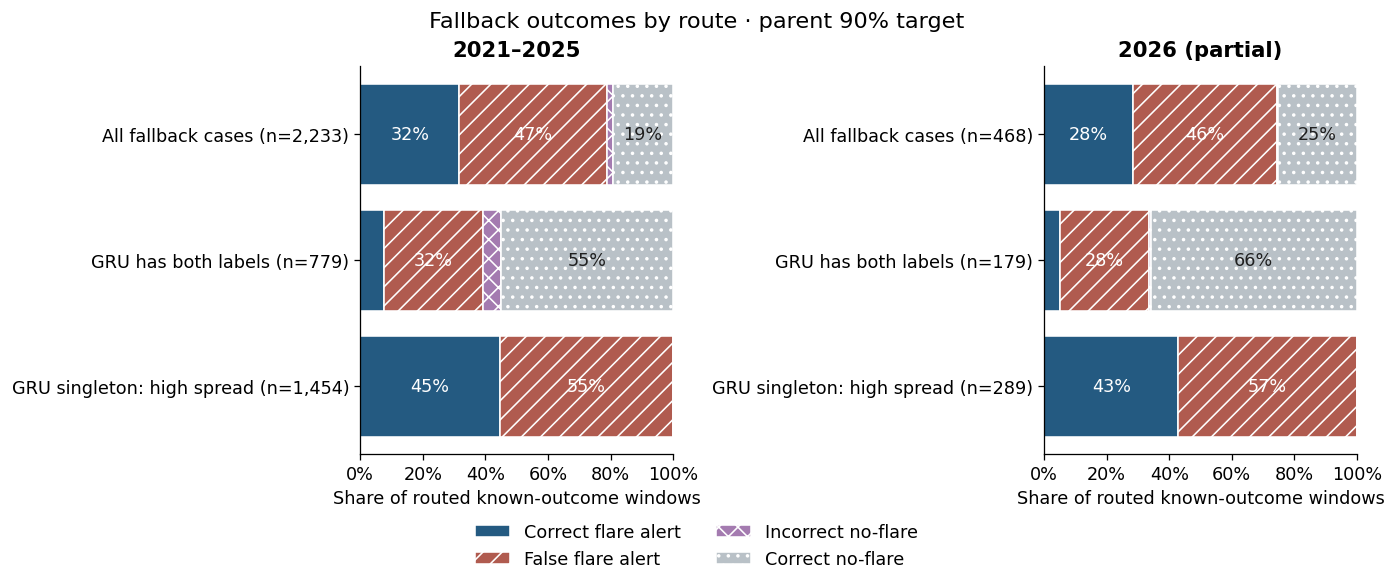

,role,route,cases,true_alerts,false_alerts,false_clears,true_clears,alert_precision,clear_error_rate
0,retrospective_cycle25,all_fallback,2233,707,1053,45,428,0.4017,0.0951
1,retrospective_cycle25,ambiguous_gru,779,58,248,45,428,0.1895,0.0951
2,retrospective_cycle25,spread_blocked_singleton,1454,649,805,0,0,0.4464,NaN
3,supplementary_2026,all_fallback,468,133,216,1,118,0.3811,0.0084
4,supplementary_2026,ambiguous_gru,179,9,51,1,118,0.1500,0.0084
5,supplementary_2026,spread_blocked_singleton,289,124,165,0,0,0.4291,NaN


In [9]:
fig,axes=plt.subplots(1,2,figsize=(12,5),sharex=True,layout='constrained')
route_order=['all_fallback','ambiguous_gru','spread_blocked_singleton'];route_labels=['All fallback cases','GRU has both labels','GRU singleton: high spread']
parts=[('true_alerts','Correct flare alert','#245A81',''),('false_alerts','False flare alert','#B05B4F','//'),('false_clears','Incorrect no-flare','#A47BB0','xx'),('true_clears','Correct no-flare','#B9C1C7','..')]
for ax,role in zip(axes,['retrospective_cycle25','supplementary_2026']):
    table=fallback[fallback.role.eq(role)&fallback.alpha.eq(.1)].set_index('route').loc[route_order];left=np.zeros(3)
    for field,label,color,hatch in parts:
        v=(table[field]/table.cases.replace(0,np.nan)).fillna(0).to_numpy();ax.barh(np.arange(3),v,left=left,color=color,hatch=hatch,edgecolor='white',label=label)
        for i,w in enumerate(v):
            if w>=.09:ax.text(left[i]+w/2,i,f'{w:.0%}',ha='center',va='center',color='white' if field in ['true_alerts','false_alerts'] else '#202020')
        left+=v
    ax.set(yticks=np.arange(3),yticklabels=[f'{label} (n={int(n):,})' for label,n in zip(route_labels,table.cases)],xlim=(0,1),xlabel='Share of routed known-outcome windows',title=PERIODS[role]);ax.invert_yaxis();ax.xaxis.set_major_formatter(PercentFormatter(1))
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside lower center',ncol=2,frameon=False)
fig.suptitle('Fallback outcomes by route · parent 90% target',fontsize=14)
fig.savefig(OUTPUT_DIR/'fallback_error_types.png',bbox_inches='tight');plt.show()
display(fallback[fallback.alpha.eq(.1)&fallback.role.ne('policy_validation')][['role','route','cases','true_alerts','false_alerts','false_clears','true_clears','alert_precision','clear_error_rate']].round(4).reset_index(drop=True))

### 9. Retain the complete comparisons
The table shows primary-level later comparisons; the CSV preserves both levels and reused development results. This is diagnostic evidence, not a leaderboard for choosing a deployable winner.

In [10]:
for role in ['retrospective_cycle25','supplementary_2026']:
    display(Markdown('**'+PERIODS[role]+'**'))
    display(metrics[metrics.role.eq(role)&metrics.alpha.eq(.1)][['active_guards','issued','selective_error','true_alerts','false_alerts','false_clears','deferred_flares']].round(4).reset_index(drop=True))
for name,digest in summary['output_sha256'].items():assert sha256(OUTPUT_DIR/name)==digest,name
print('Frozen artifacts verified; no operational policy changed.')

**2021–2025**

,active_guards,issued,selective_error,true_alerts,false_alerts,false_clears,deferred_flares
0,none,22919,0.1693,2148,3416,465,1247
1,support,22388,0.1547,2035,2998,465,1360
2,distance,22492,0.1722,2145,3413,459,1256
3,support+distance,21961,0.1573,2032,2995,459,1369
4,spread,21267,0.1395,1411,2501,465,1984
5,support+spread,20859,0.1258,1345,2159,465,2050
6,distance+spread,20846,0.1420,1411,2501,459,1990
7,support+distance+spread,20438,0.1281,1345,2159,459,2056
8,conflict,22916,0.1694,2148,3416,465,1247
9,support+conflict,22385,0.1547,2035,2998,465,1360


**2026 (partial)**

,active_guards,issued,selective_error,true_alerts,false_alerts,false_clears,deferred_flares
0,none,6960,0.1700,411,968,215,366
1,support,6960,0.1700,411,968,215,366
2,distance,6497,0.1758,411,968,174,407
3,support+distance,6497,0.1758,411,968,174,407
4,spread,6671,0.1526,287,803,215,490
5,support+spread,6671,0.1526,287,803,215,490
6,distance+spread,6208,0.1574,287,803,174,531
7,support+distance+spread,6208,0.1574,287,803,174,531
8,conflict,6960,0.1700,411,968,215,366
9,support+conflict,6960,0.1700,411,968,215,366


Frozen artifacts verified; no operational policy changed.


## Takeaways

**The fallback does not resolve the disagreement in its largest route.** In the high-spread singleton route it reinstates exactly the original GRU decision: all 1,454 such cases in 2021–2025 and 289 in partial 2026 are flare alerts at the primary level. That route accounts for about 65% and 62% of fallback windows. A model switch should not be treated as independent evidence that a rejected decision is now trustworthy.

The guard tradeoff is direction-dependent. The distance guard uniquely removes some false clears, while the disagreement guard suppresses both useful flare alerts and false alarms. This supports investigating separate alert and no-flare policies, with explicit review/deferral handling. It does not establish which errors operators should tolerate.

In [11]:
messages=[]
for role in ['retrospective_cycle25','supplementary_2026']:
    t=attribution[attribution.role.eq(role)&attribution.alpha.eq(.1)].set_index('guard')
    largest=t.allocated_true_alert.idxmax();total=t.allocated_true_alert.sum();r=t.loc[largest]
    f=fallback[fallback.role.eq(role)&fallback.alpha.eq(.1)&fallback.route.eq('all_fallback')].iloc[0]
    messages.append(f'**{PERIODS[role]}:** {GUARD_LABELS[largest]} receives {r.allocated_true_alert:.1f} of {total:.0f} suppressed true-alert windows in the shared allocation. Dropping it alone would recover {int(r.unique_true_alert)} true alerts and restore {int(r.unique_false_alert)} false alerts plus {int(r.unique_false_clear)} false clears.')
    messages.append(f'The fallback makes {int(f.false_alerts)} false alerts and {int(f.false_clears)} false clears; its {int(f.alert_decisions)} positive decisions include {int(f.true_alerts)} correct flare alerts ({f.alert_precision:.1%} precision).')
display(Markdown('\n\n'.join(messages)))
display(Markdown('### Interpretation limits\n'+'\n'.join('- '+s for s in summary['limitations'])))

**2021–2025:** Seed disagreement receives 712.0 of 803 suppressed true-alert windows in the shared allocation. Dropping it alone would recover 687 true alerts and restore 836 false alerts plus 0 false clears.

The fallback makes 1053 false alerts and 45 false clears; its 1760 positive decisions include 707 correct flare alerts (40.2% precision).

**2026 (partial):** Seed disagreement receives 124.0 of 124 suppressed true-alert windows in the shared allocation. Dropping it alone would recover 124 true alerts and restore 165 false alerts plus 0 false clears.

The fallback makes 216 false alerts and 1 false clears; its 349 positive decisions include 133 correct flare alerts (38.1% precision).

### Interpretation limits
- This is a post-hoc diagnostic of already inspected data and provisional labels. No new thresholds or operational policy are selected.
- Guard contributions describe deterministic routing of frozen decisions, not causes of solar activity, causes of model error or independently validated improvements.
- Standalone guard counts overlap. Unique counts measure dropping one guard while keeping the other three. Equal allocation shares each removed case among its triggered guards and reconciles totals; it is not a unique scientific attribution.
- A false alert prevented and a true alert suppressed have different operational values. Raw counts and selective error do not supply an agreed cost or utility.
- Conditional paired intervals use region or time-block resampling of realized predictions; model fitting, rolling calibration, threshold selection and label uncertainty are not repeated. Intervals are per comparison, without multiplicity correction.
- Windows overlap and are not independent flare events. Matched known-outcome metrics exclude unknown labels and missing inputs, which remain in the full-population diagnostic table.
- The diagnostic does not change the q99 feature-distance or q95 seed-spread thresholds. Removing the support guard is an accounting ablation, not approval to issue forecasts with weak calibration support.
- Fallback cases are selected difficult cases. Their error rate is not the logistic model error rate across the entire population. Neither backbone nor fallback is operationally certified.

**Refinement to consider after this diagnostic:** treat flare alerts and no-flare decisions as separate operating decisions when defining error tolerance and escalation. Keep hard input/availability checks and the calibration-support requirement explicit. Investigate whether disagreement should trigger review rather than the current binary fallback, and evaluate that change in a declared future protocol. This notebook does not make that change or retune thresholds on 2026.

**Reusable outputs:** full-population guard masks and fallback routes, every guard subset, exact overlap counts, standalone/unique/shared contributions, annual contributions, paired conditional intervals and the frozen source contract.